In [12]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from pathlib import Path
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
import pmdarima as pm
from sklearn.metrics import mean_absolute_error, mean_squared_error

DATA_FILE = Path("./stock_common_clean.csv")
TICKERS = ["FPT", "HPG", "VCB", "VIC", "VNM"]

all_stocks = pd.read_csv(DATA_FILE, parse_dates=["trading_date"])
all_stocks = all_stocks.sort_values(["stock_code", "trading_date"]).reset_index(drop=True)

def load_ticker(ticker):
    df = all_stocks[all_stocks["stock_code"] == ticker].copy()
    df = df.reset_index(drop=True)
    # remove rows flagged as bad data - corrupted ohlc, no trades, or known exchange outage
    bad = (df["ohlc_invalid"] == 1) | (df["zero_volume"] == 1) | (df["hose_disruption"] == 1)
    df = df[~bad].reset_index(drop=True)
    return df

In [18]:
# STEP 1 - ADF STATIONARITY TEST
# H0: the series is not stationary
# if p-value < 0.05 -> reject H0 -> series is stationary -> safe to use ARIMA

def run_adf_test(series, ticker):
    result = adfuller(series.dropna(), autolag="AIC")
    adf_stat = result[0]
    p_value = result[1]
    critical_values = result[4]

    print(f"\nADF Stationarity Test - {ticker}")
    print(f"ADF Statistic: {adf_stat:.4f}")
    print(f"p-value: {p_value:.6f}")
    for level, cv in critical_values.items():
        print(f"Critical ({level}) : {cv:.4f}")

    if p_value < 0.05:
        print("Result: Stationary (p < 0.05) - good to go with ARIMA")
    else:
        print("Result: Not stationary (p > 0.05) - needs differencing")

    return {"ticker": ticker, "adf_stat": adf_stat, "p_value": p_value}

In [5]:
# STEP 2 - ACF AND PACF PLOTS - show how much influence past days have on today's return.
# ACF: correlation between today and k days ago, including all indirect paths; used to pick q (MA order)
# PACF: same but removes indirect effects, shows only the direct relationship; used to pick p (AR order)
# shaded band = 95% confidence interval - bars outside = significant, inside = noise

def plot_acf_pacf(series, ticker, lags=40):
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    fig.suptitle(f"ACF & PACF - {ticker} log_return", fontsize=13, fontweight="bold")
    plot_acf(series.dropna(), lags=lags, ax=axes[0], title="ACF (helps pick q)")
    plot_pacf(series.dropna(), lags=lags, ax=axes[1], title="PACF (helps pick p)", method="ywm") # ywm = Yule-Walker method, standard choice for PACF estimation
    plt.tight_layout()
    plt.show()

In [6]:
# STEP 3 - TRAIN / TEST SPLIT
# first 80% = training, last 20% = testing

def time_series_split(df, test_ratio=0.2):
    split_idx = int(len(df) * (1 - test_ratio))
    train = df.iloc[:split_idx].copy()
    test = df.iloc[split_idx:].copy()
    print(f"Train: {train['trading_date'].min().date()} to {train['trading_date'].max().date()} ({len(train)} rows)")
    print(f"Test: {test['trading_date'].min().date()} to {test['trading_date'].max().date()} ({len(test)} rows)")
    return train, test

In [7]:
# STEP 4 - AUTO-ARIMA
# searches all (p, 0, q) combinations and picks the one with lowest AIC
# d=0 because log_return is already stationary, no differencing needed

def fit_auto_arima(train_series, ticker):
    print(f"\nFitting Auto-ARIMA for {ticker}...")
    model = pm.auto_arima(
        train_series.dropna(),
        d=0,
        max_p=5, max_q=5,
        information_criterion="aic",
        stepwise=True
    )
    print(f"Best order: ARIMA{model.order}")
    print(f"AIC: {model.aic():.2f}")
    print(f"BIC: {model.bic():.2f}")
    return model

In [8]:
# STEP 5 - ROLLING WALK-FORWARD FORECAST
# for each test day: fit on all past data, predict one day ahead, then add the real value to history and repeat

def rolling_forecast(model, train_series, test_series):
    history = list(train_series.dropna())
    predictions = []
    order = model.order

    print(f"Rolling forecast over {len(test_series)} test days...")
    for i in range(len(test_series)):
        m = pm.ARIMA(order=order)
        m.fit(history)
        yhat = m.predict(n_periods=1)[0]
        predictions.append(yhat)
        history.append(test_series.iloc[i])

    return np.array(predictions)

In [9]:
# STEP 6 - FORECAST METRICS

def compute_metrics(y_true, y_pred, ticker):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    mask = np.abs(y_true) > 1e-6
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

    print(f"\nForecast Metrics - {ticker}")
    print(f"MAE: {mae:.6f}")
    print(f"RMSE: {rmse:.6f}")
    print(f"MAPE: {mape:.2f}%")

    return {"ticker": ticker, "MAE": mae, "RMSE": rmse, "MAPE": mape}

In [14]:
# STEP 7 - RESIDUAL DIAGNOSTICS
# residuals: the difference between predicted and actual price; a good model leaves residuals that look like pure random noise:
#  - no autocorrelation (no pattern left over)
#  - roughly normally distributed
# Ljung-Box: tests whether residuals have remaining autocorrelation.
#  - H0: residuals are white noise (what we want)
#  - p > 0.05 -> cannot reject H0 -> residuals look clean
#  - p < 0.05 -> autocorrelation still present -> model missed something
# Durbin-Watson: checks serial correlation at lag 1 - ideal = 2.0, acceptable range = 1.5 to 2.5
# Q-Q plot: checks if residuals are normally distributed - points on the diagonal line = normal; curved tails are common and expected in financial data

def residual_diagnostics(model, ticker):
    residuals = pd.Series(model.resid())

    lb = acorr_ljungbox(residuals, lags=[10, 20], return_df=True)
    lb_ok = (lb["lb_pvalue"] > 0.05).all()
    print(f"\nLjung-Box Test - {ticker}")
    print(lb[["lb_stat", "lb_pvalue"]].to_string())
    if lb_ok:
        print("-> Residuals look like white noise (no autocorrelation left)")
    else:
        print("-> Autocorrelation still in residuals - model may need higher p or q")

    dw = durbin_watson(residuals)
    print(f"\nDurbin-Watson: {dw:.4f}  (ideal = 2.0, acceptable = 1.5 to 2.5)")
    if 1.5 < dw < 2.5:
        print("-> Within acceptable range")
    else:
        print("-> Outside acceptable range")

    fig = plt.figure(figsize=(16, 9))
    fig.suptitle(f"Residual Diagnostics - {ticker}", fontsize=14, fontweight="bold")
    gs = gridspec.GridSpec(2, 3, figure=fig)

    ax1 = fig.add_subplot(gs[0, :2])
    ax1.plot(residuals.values, linewidth=0.7, color="blue")
    ax1.axhline(0, color="red", linestyle="--", linewidth=0.8)
    ax1.set_title("Residuals over time (should look random, no pattern)")
    ax1.set_xlabel("Day index")

    ax2 = fig.add_subplot(gs[0, 2])
    ax2.hist(residuals, bins=40, color="blue", edgecolor="white", alpha=0.8)
    ax2.set_title("Histogram of residuals (bell-shaped = good)")

    ax3 = fig.add_subplot(gs[1, 0])
    stats.probplot(residuals, dist="norm", plot=ax3)
    ax3.set_title("Q-Q Plot (points on diagonal = normally distributed)")

    ax4 = fig.add_subplot(gs[1, 1])
    plot_acf(residuals, lags=30, ax=ax4, title="ACF of residuals (all bars inside band = good)")

    ax5 = fig.add_subplot(gs[1, 2])
    plot_pacf(residuals, lags=30, ax=ax5, title="PACF of residuals", method="ywm")

    plt.tight_layout()
    plt.show()

    return {"lb_ok": lb_ok, "dw": dw}


def plot_forecast(test_df, y_pred, ticker, n_show=120):
    dates = test_df["trading_date"].values[-n_show:]
    actual = test_df["log_return"].values[-n_show:]
    pred = y_pred[-n_show:]

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(dates, actual, label="Actual", color="darkblue", linewidth=1.2)
    ax.plot(dates, pred, label="Predicted", color="red", linewidth=1.0, linestyle="--")
    ax.axhline(0, color="grey", linewidth=0.5)
    ax.set_title(f"ARIMA Forecast vs Actual - {ticker} (last {n_show} test days)")
    ax.set_xlabel("Date")
    ax.set_ylabel("log_return")
    ax.legend()
    plt.tight_layout()
    plt.show()


##################################################
TICKER: FPT
##################################################

ADF Stationarity Test - FPT
ADF Statistic: -58.1829
p-value: 0.000000
Critical (1%) : -3.4322
Critical (5%) : -2.8624
Critical (10%) : -2.5672
Result: Stationary (p < 0.05) - good to go with ARIMA


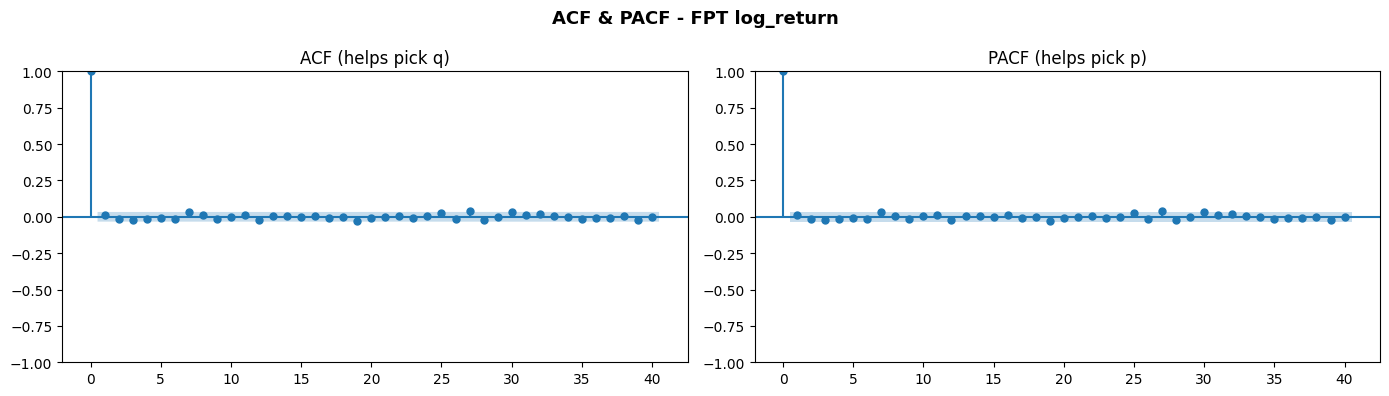


Splitting data...
Train: 2012-02-06 to 2023-03-23 (2779 rows)
Test: 2023-03-24 to 2025-12-31 (695 rows)

Fitting Auto-ARIMA for FPT...
Best order: ARIMA(0, 0, 0)
AIC: -15030.87
BIC: -15019.01
Rolling forecast over 695 test days...


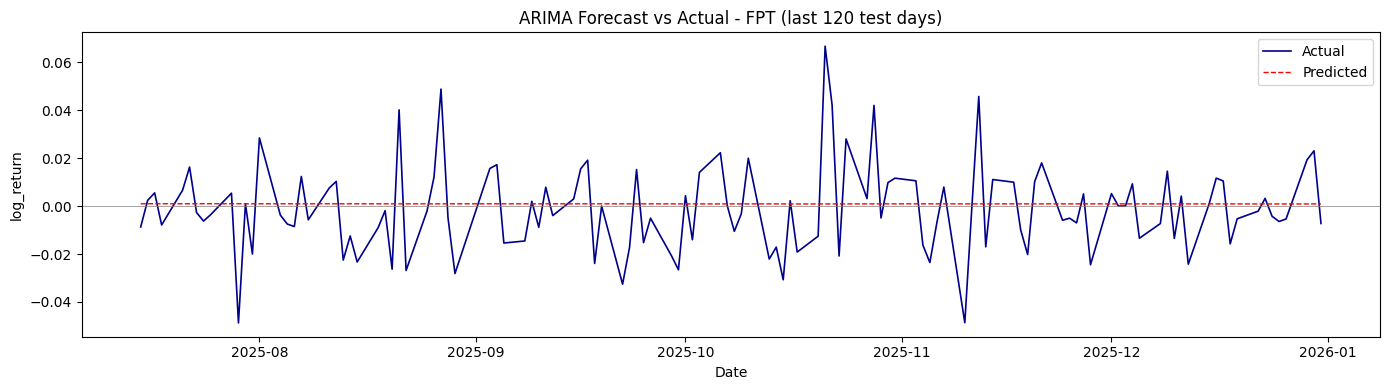


Forecast Metrics - FPT
MAE: 0.011585
RMSE: 0.016387
MAPE: 100.68%

Ljung-Box Test - FPT
      lb_stat  lb_pvalue
10   9.259805   0.507638
20  16.388535   0.692247
-> Residuals look like white noise (no autocorrelation left)

Durbin-Watson: 1.9980  (ideal = 2.0, acceptable = 1.5 to 2.5)
-> Within acceptable range


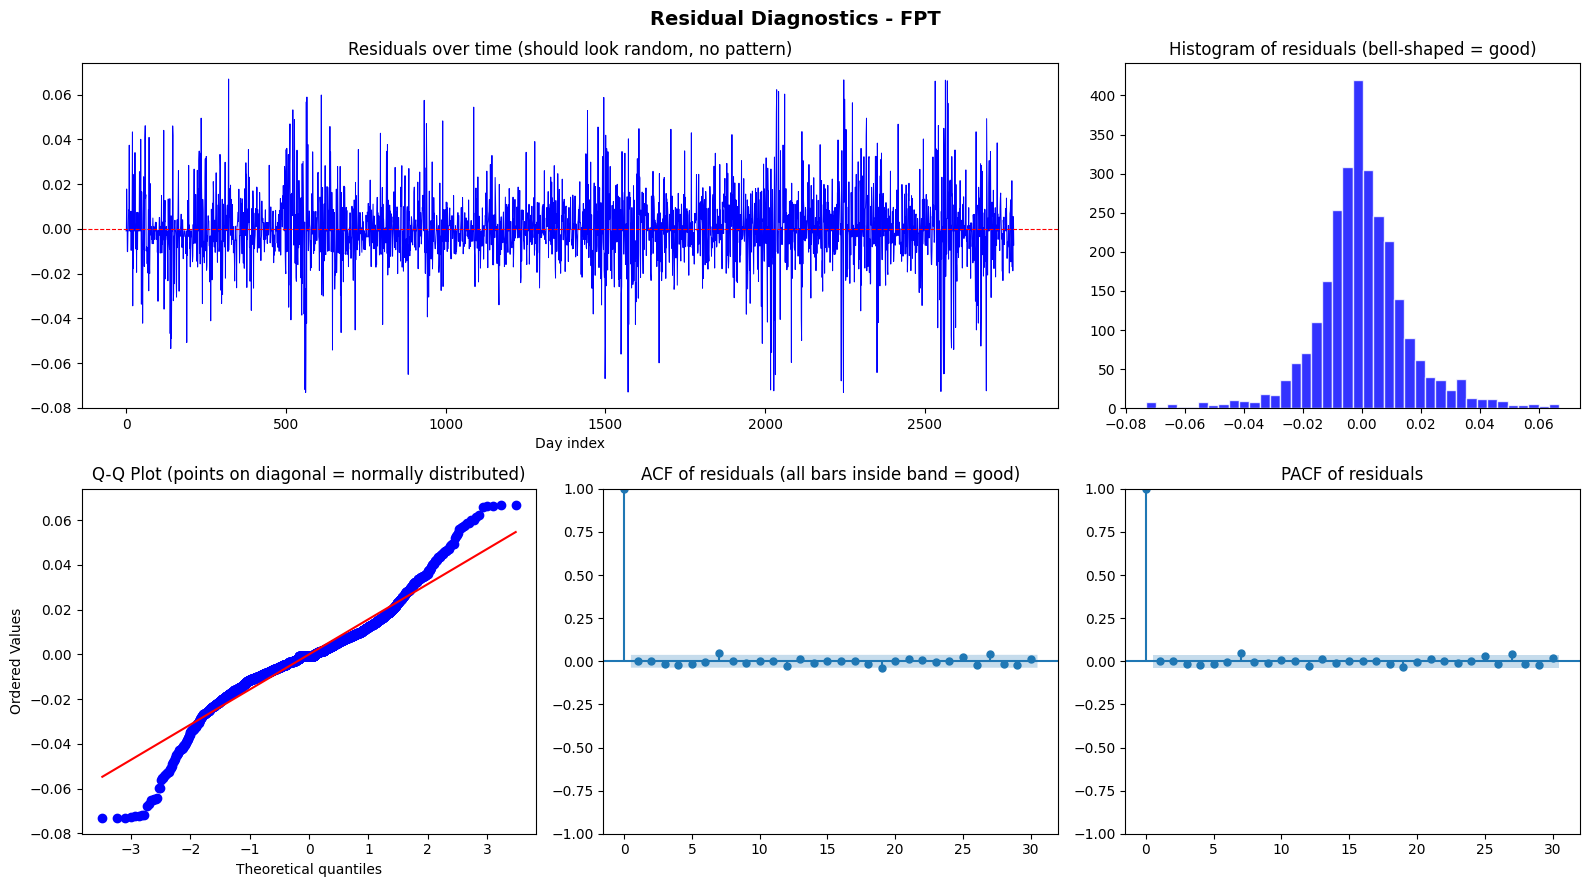


##################################################
TICKER: HPG
##################################################

ADF Stationarity Test - HPG
ADF Statistic: -14.5910
p-value: 0.000000
Critical (1%) : -3.4322
Critical (5%) : -2.8624
Critical (10%) : -2.5672
Result: Stationary (p < 0.05) - good to go with ARIMA


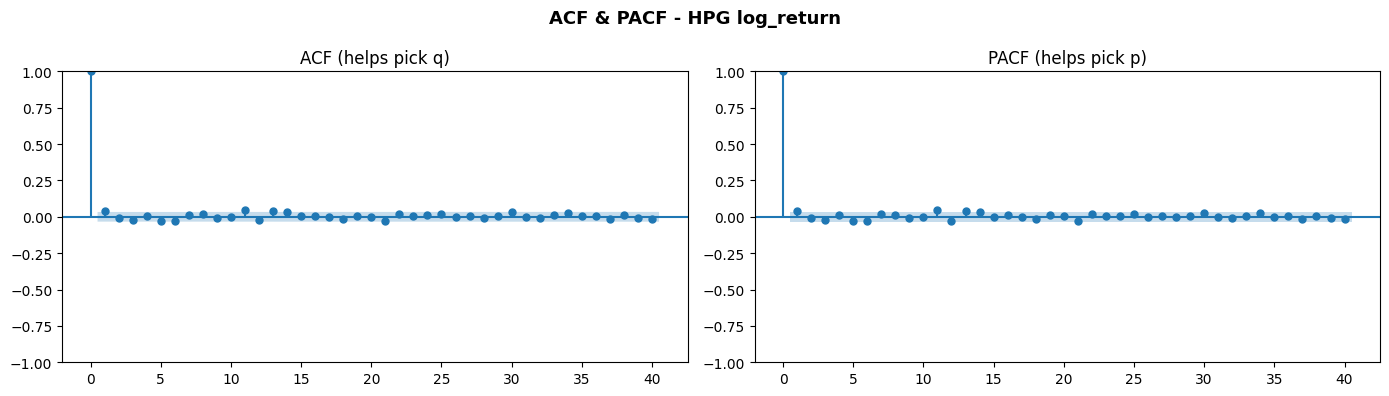


Splitting data...
Train: 2012-02-06 to 2023-03-23 (2779 rows)
Test: 2023-03-24 to 2025-12-31 (695 rows)

Fitting Auto-ARIMA for HPG...
Best order: ARIMA(0, 0, 1)
AIC: -13327.74
BIC: -13309.95
Rolling forecast over 695 test days...


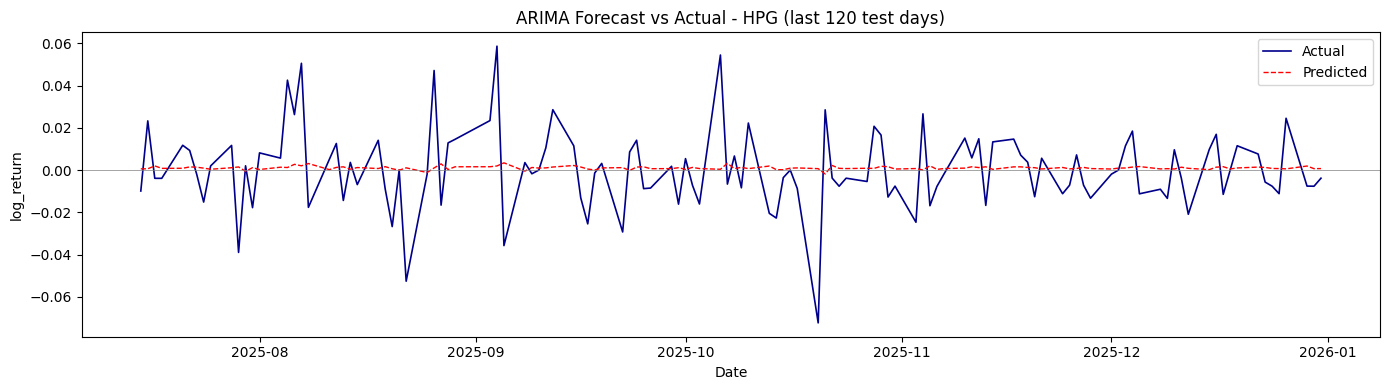


Forecast Metrics - HPG
MAE: 0.011841
RMSE: 0.016668
MAPE: 101.94%

Ljung-Box Test - HPG
      lb_stat  lb_pvalue
10  12.962537   0.225774
20  32.740759   0.036017
-> Autocorrelation still in residuals - model may need higher p or q

Durbin-Watson: 1.9988  (ideal = 2.0, acceptable = 1.5 to 2.5)
-> Within acceptable range


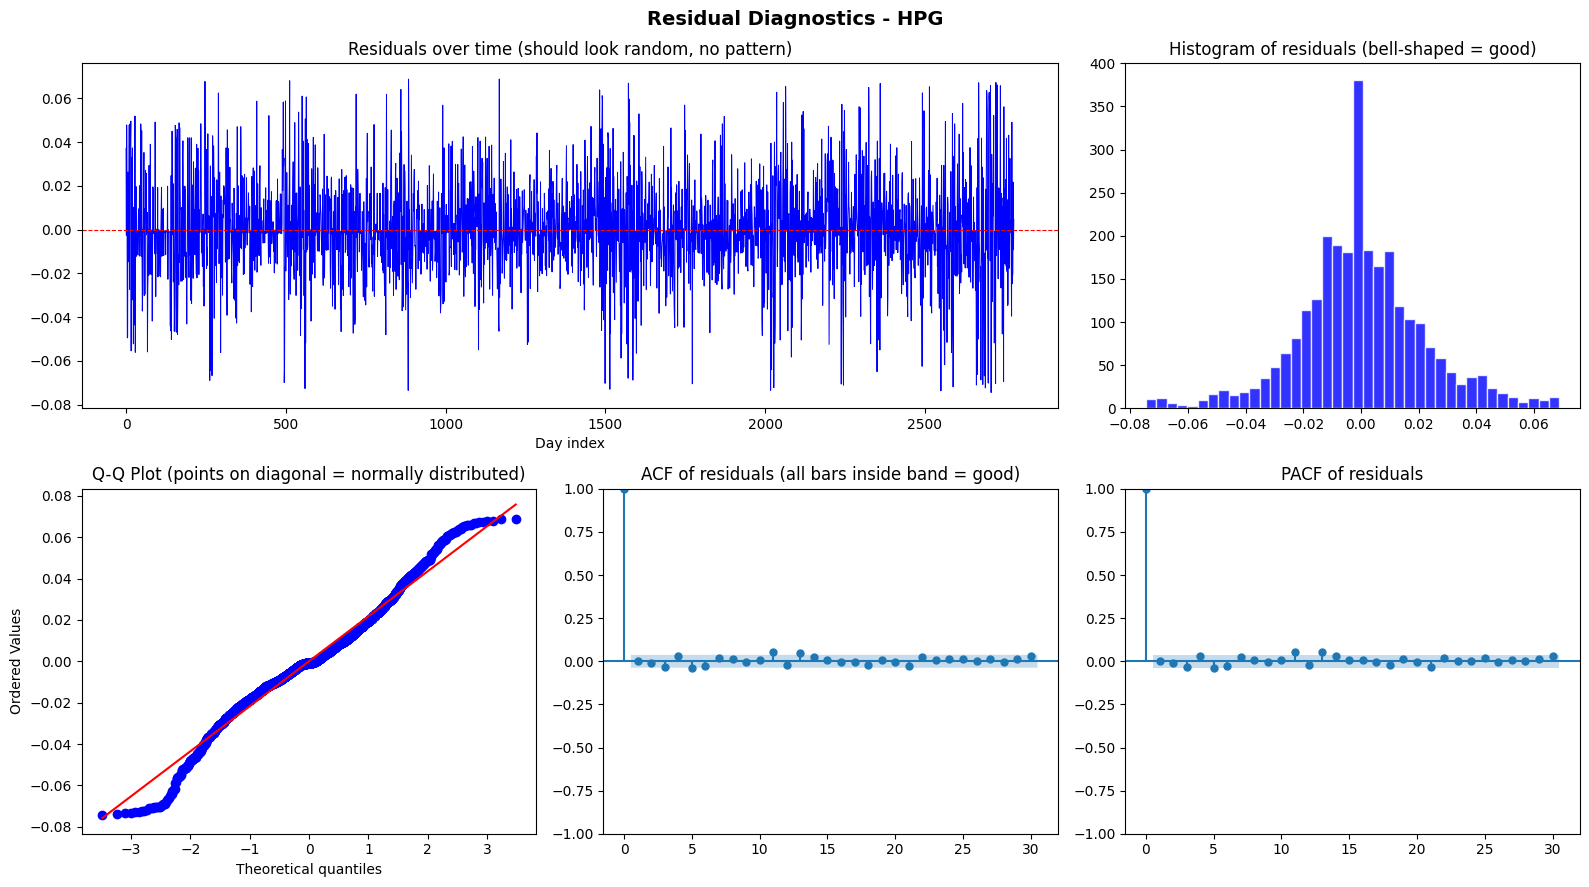


##################################################
TICKER: VCB
##################################################

ADF Stationarity Test - VCB
ADF Statistic: -57.8113
p-value: 0.000000
Critical (1%) : -3.4322
Critical (5%) : -2.8624
Critical (10%) : -2.5672
Result: Stationary (p < 0.05) - good to go with ARIMA


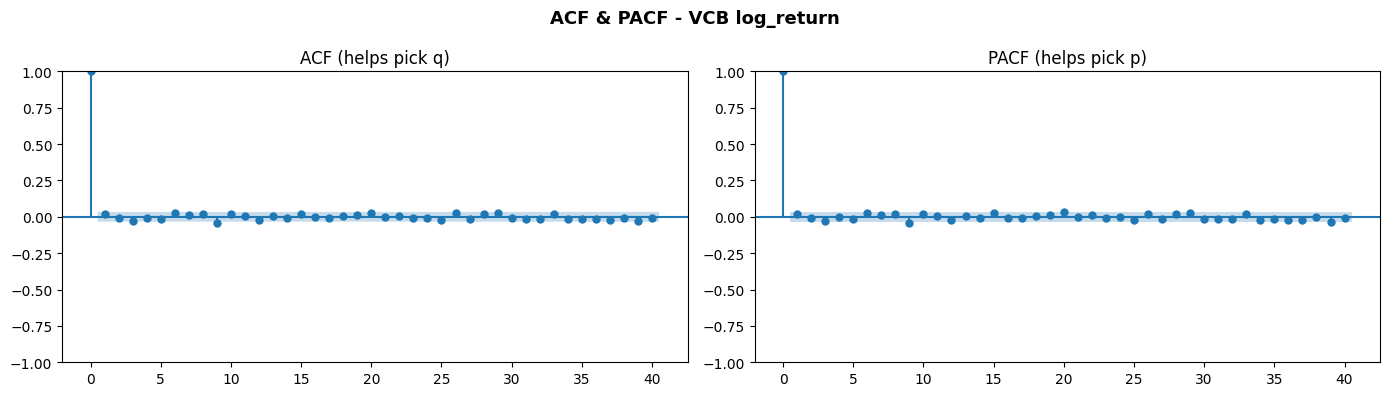


Splitting data...
Train: 2012-02-06 to 2023-03-23 (2779 rows)
Test: 2023-03-24 to 2025-12-31 (695 rows)

Fitting Auto-ARIMA for VCB...
Best order: ARIMA(0, 0, 0)
AIC: -14088.37
BIC: -14076.51
Rolling forecast over 695 test days...


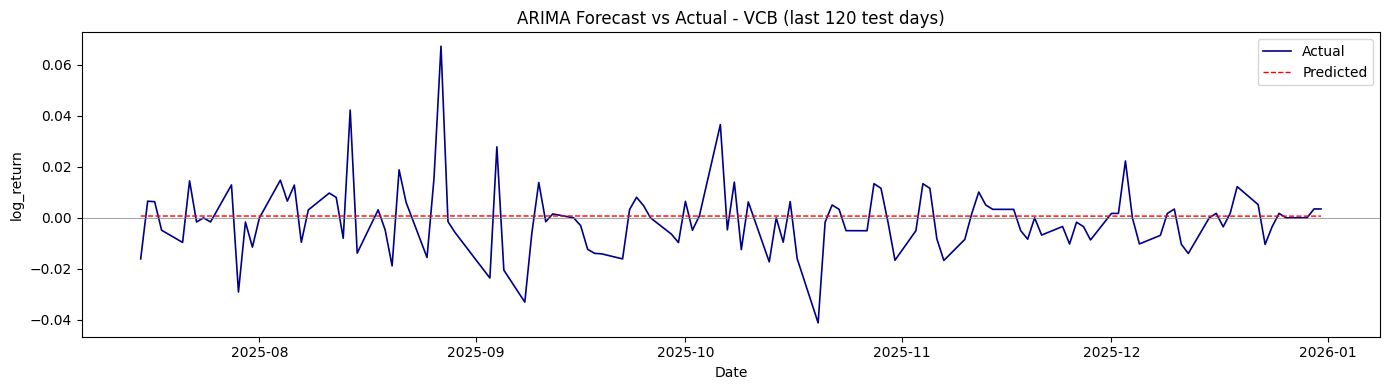


Forecast Metrics - VCB
MAE: 0.008485
RMSE: 0.012641
MAPE: 99.64%

Ljung-Box Test - VCB
      lb_stat  lb_pvalue
10  17.100838   0.072162
20  23.726391   0.254548
-> Residuals look like white noise (no autocorrelation left)

Durbin-Watson: 1.9625  (ideal = 2.0, acceptable = 1.5 to 2.5)
-> Within acceptable range


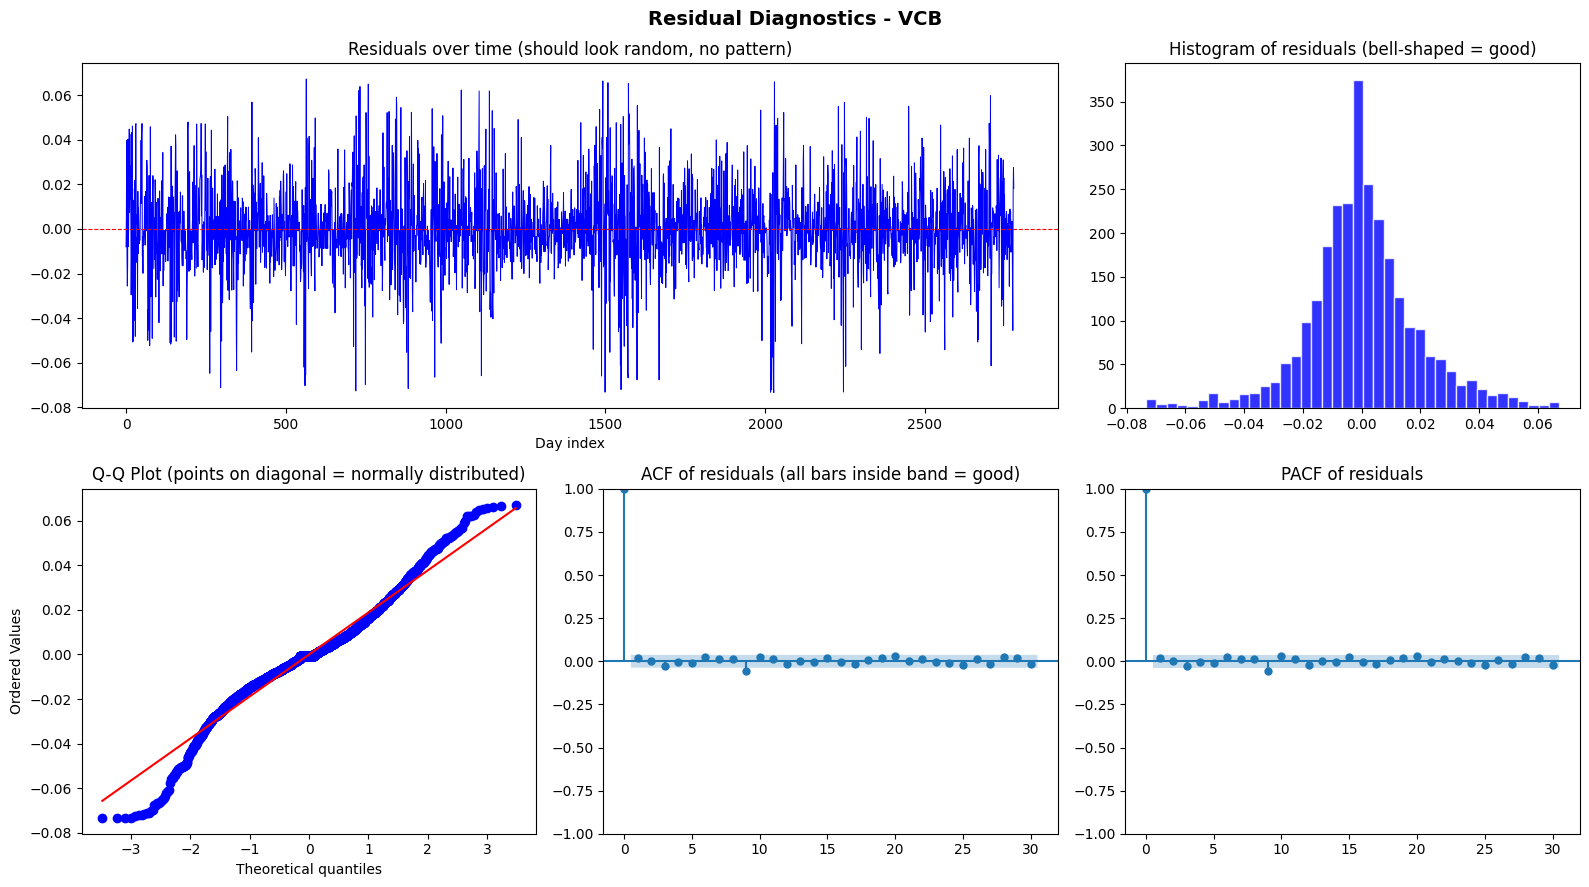


##################################################
TICKER: VIC
##################################################

ADF Stationarity Test - VIC
ADF Statistic: -54.0832
p-value: 0.000000
Critical (1%) : -3.4322
Critical (5%) : -2.8624
Critical (10%) : -2.5672
Result: Stationary (p < 0.05) - good to go with ARIMA


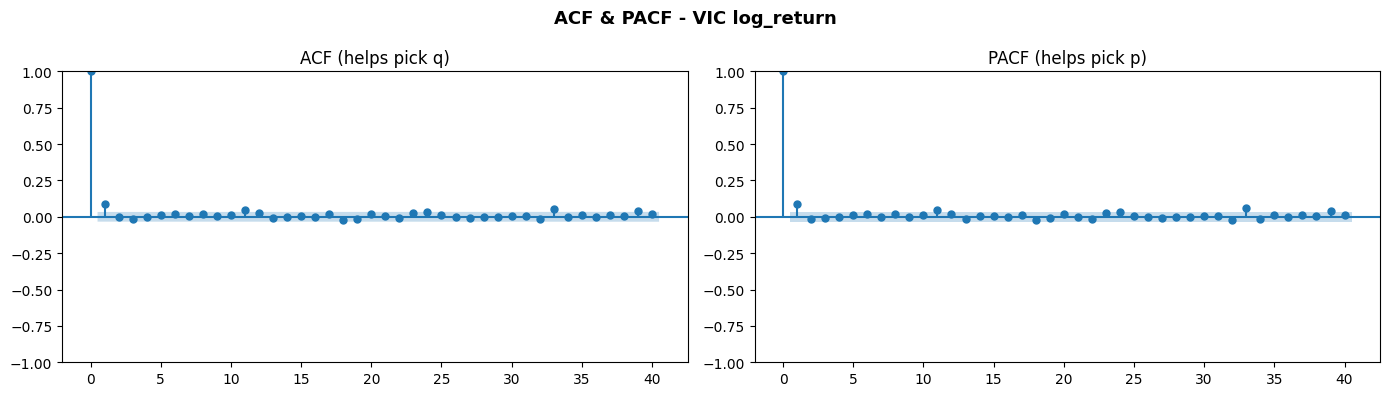


Splitting data...
Train: 2012-02-06 to 2023-03-23 (2779 rows)
Test: 2023-03-24 to 2025-12-31 (695 rows)

Fitting Auto-ARIMA for VIC...
Best order: ARIMA(0, 0, 0)
AIC: -14539.80
BIC: -14533.87
Rolling forecast over 695 test days...


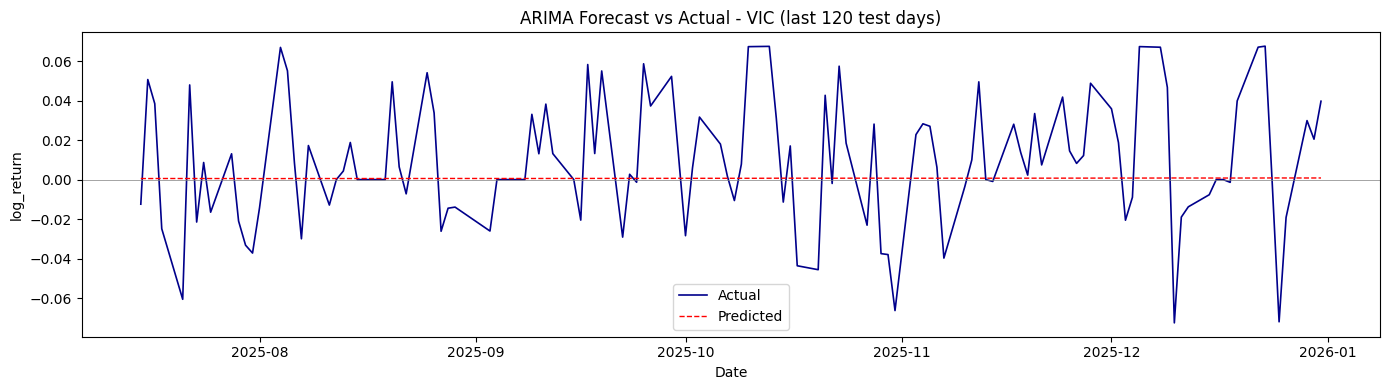


Forecast Metrics - VIC
MAE: 0.015171
RMSE: 0.023749
MAPE: 99.94%

Ljung-Box Test - VIC
      lb_stat  lb_pvalue
10   3.841721   0.954205
20  15.326249   0.757445
-> Residuals look like white noise (no autocorrelation left)

Durbin-Watson: 1.9580  (ideal = 2.0, acceptable = 1.5 to 2.5)
-> Within acceptable range


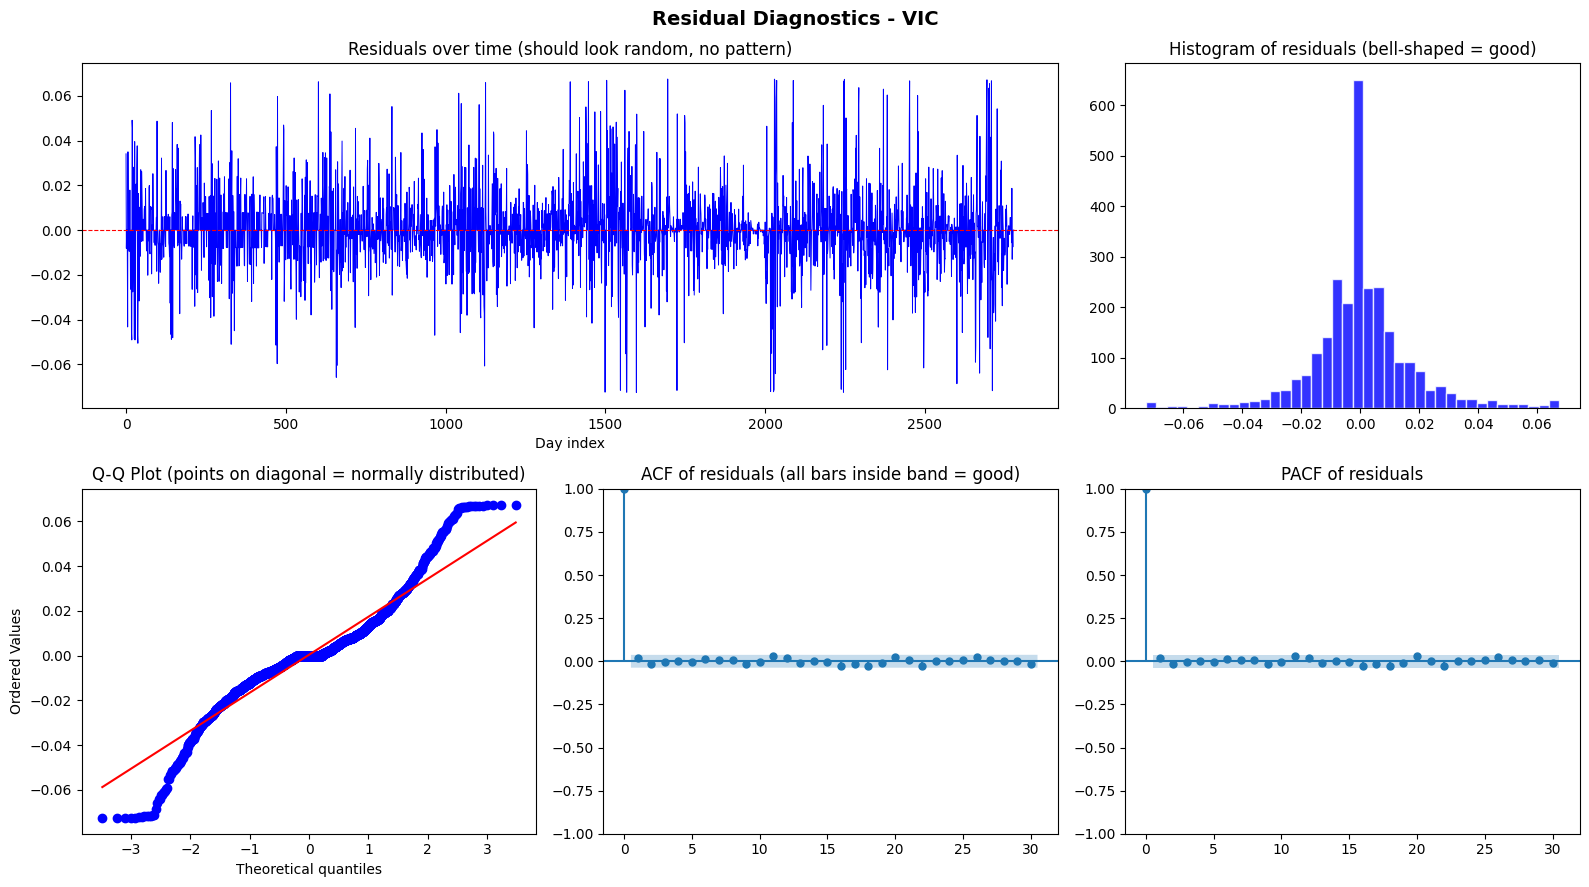


##################################################
TICKER: VNM
##################################################

ADF Stationarity Test - VNM
ADF Statistic: -31.4268
p-value: 0.000000
Critical (1%) : -3.4322
Critical (5%) : -2.8624
Critical (10%) : -2.5672
Result: Stationary (p < 0.05) - good to go with ARIMA


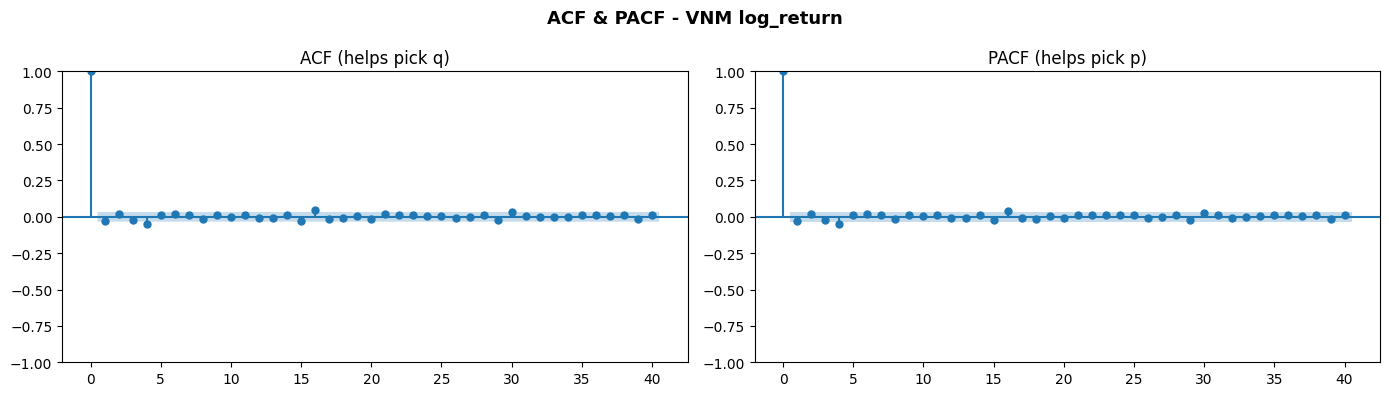


Splitting data...
Train: 2012-02-06 to 2023-03-23 (2779 rows)
Test: 2023-03-24 to 2025-12-31 (695 rows)

Fitting Auto-ARIMA for VNM...
Best order: ARIMA(0, 0, 4)
AIC: -15433.87
BIC: -15398.29
Rolling forecast over 695 test days...


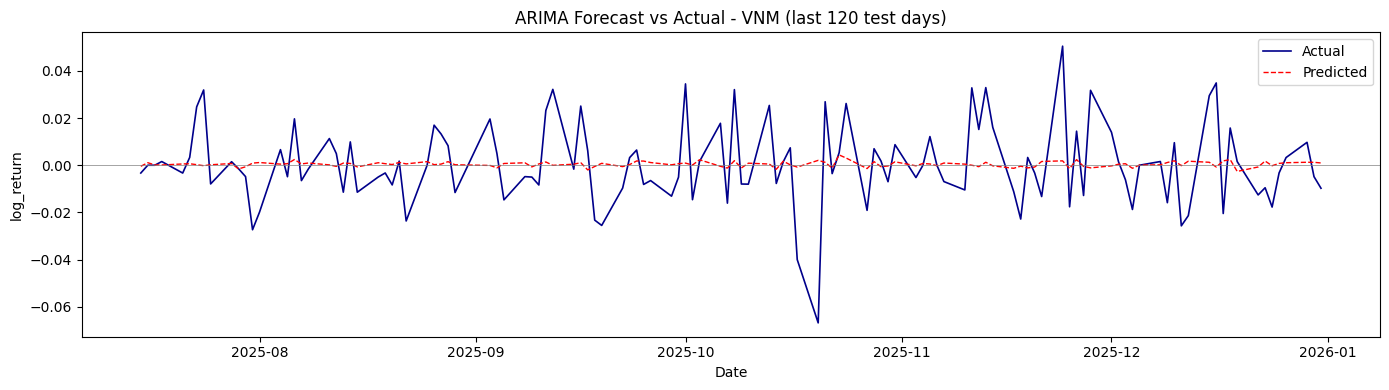


Forecast Metrics - VNM
MAE: 0.009285
RMSE: 0.013376
MAPE: 100.44%

Ljung-Box Test - VNM
      lb_stat  lb_pvalue
10   3.018818   0.980978
20  14.445855   0.807190
-> Residuals look like white noise (no autocorrelation left)

Durbin-Watson: 1.9975  (ideal = 2.0, acceptable = 1.5 to 2.5)
-> Within acceptable range


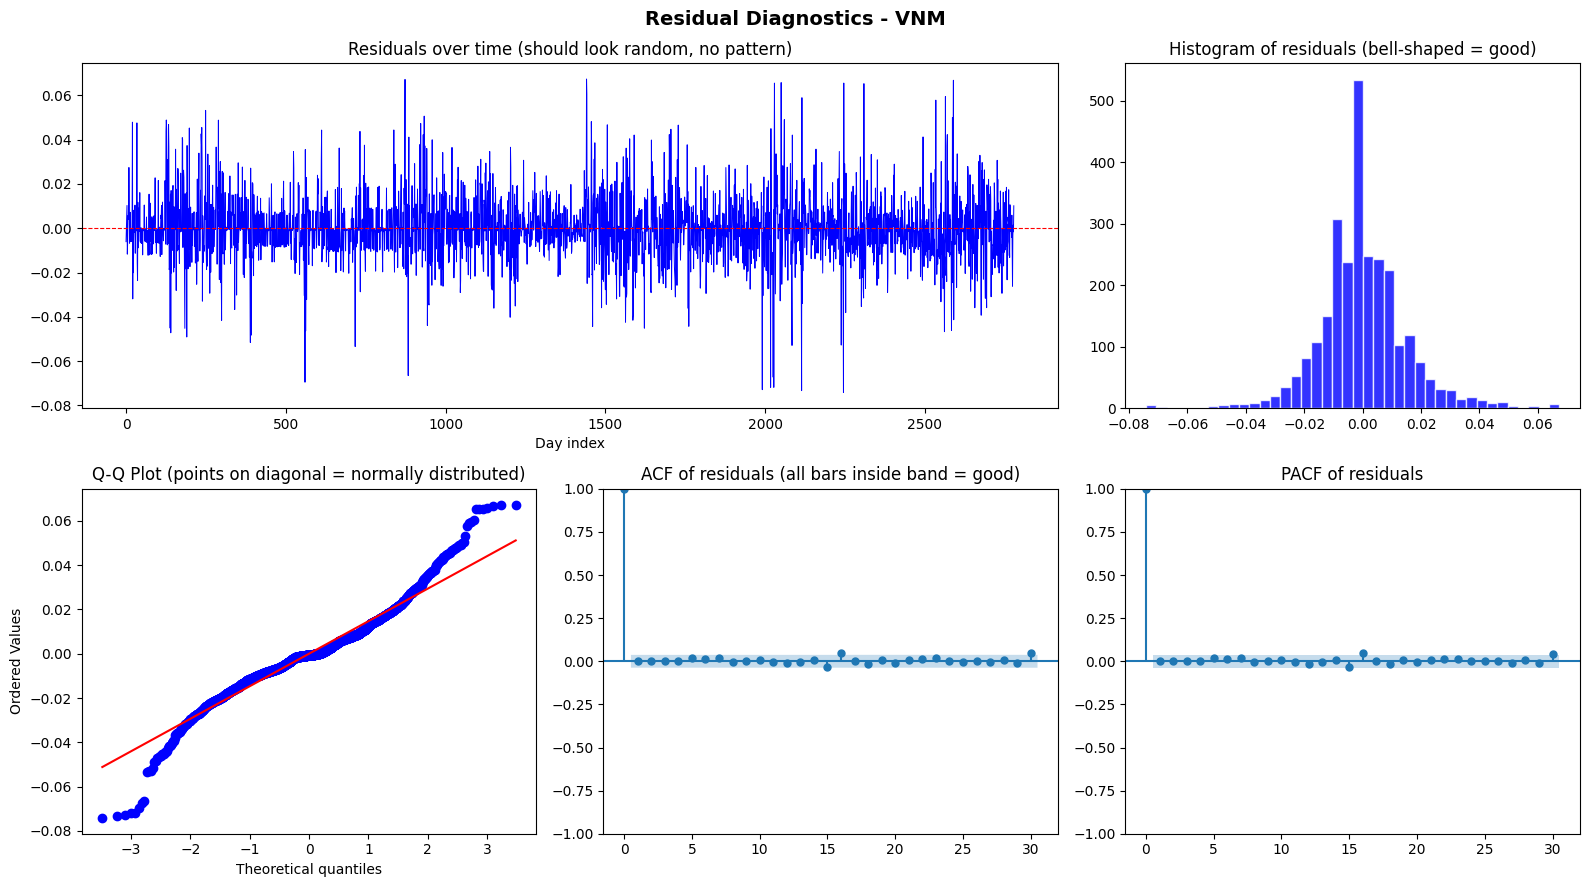


SUMMARY - ALL TICKERS
Ticker ARIMA Order       AIC       BIC      MAE     RMSE   MAPE (%)  ADF p-value  Durbin-Watson  Ljung-Box OK
   FPT   (0, 0, 0) -15030.87 -15019.01 0.011585 0.016387 100.678085 0.000000e+00       1.997994          True
   HPG   (0, 0, 1) -13327.74 -13309.95 0.011841 0.016668 101.940098 4.314552e-27       1.998845         False
   VCB   (0, 0, 0) -14088.37 -14076.51 0.008485 0.012641  99.637581 0.000000e+00       1.962505          True
   VIC   (0, 0, 0) -14539.80 -14533.87 0.015171 0.023749  99.941798 0.000000e+00       1.958029          True
   VNM   (0, 0, 4) -15433.87 -15398.29 0.009285 0.013376 100.435096 0.000000e+00       1.997483          True


In [19]:
# MAIN
def run_arima_pipeline(ticker):
    print(f"\n{'#'*50}")
    print(f"TICKER: {ticker}")
    print(f"{'#'*50}")

    df = load_ticker(ticker)
    series = df["log_return"].dropna()

    adf_result = run_adf_test(series, ticker)
    plot_acf_pacf(series, ticker)

    print("\nSplitting data...")
    train_df, test_df = time_series_split(df)
    train_series = train_df["log_return"].dropna()
    test_series = test_df["log_return"].dropna()

    model = fit_auto_arima(train_series, ticker)
    y_pred = rolling_forecast(model, train_series, test_series)
    y_true = test_series.values[:len(y_pred)]

    plot_forecast(test_df.iloc[:len(y_pred)], y_pred, ticker)

    metrics = compute_metrics(y_true, y_pred, ticker)
    diag = residual_diagnostics(model, ticker)

    return {
        "ticker": ticker,
        "arima_order": model.order,
        "aic": round(model.aic(), 2),
        "bic": round(model.bic(), 2),
        "MAE": metrics["MAE"],
        "RMSE": metrics["RMSE"],
        "MAPE": metrics["MAPE"],
        "adf_p_value": adf_result["p_value"],
        "dw": diag["dw"],
        "lb_ok": diag["lb_ok"],
    }


def main():
    all_results = []
    for ticker in TICKERS:
        result = run_arima_pipeline(ticker)
        all_results.append(result)

    summary = pd.DataFrame(all_results)
    summary.columns = [
        "Ticker", "ARIMA Order", "AIC", "BIC",
        "MAE", "RMSE", "MAPE (%)",
        "ADF p-value", "Durbin-Watson", "Ljung-Box OK"
    ]

    print("\n" + "="*75)
    print("SUMMARY - ALL TICKERS")
    print("="*75)
    print(summary.to_string(index=False))


if __name__ == "__main__":
    main()